In [1]:
from google.colab import files

In [2]:
!unzip "Experiment 5_Dataset-20260207T042443Z-1-001.zip"

Archive:  Experiment 5_Dataset-20260207T042443Z-1-001.zip
  inflating: Experiment 5_Dataset/Experiment_5 dataset/english.csv  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img060-019.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img062-016.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img062-026.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img061-009.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img061-055.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img061-018.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img062-006.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img062-036.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img061-019.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img061-014.png  
  inflating: Experiment 5_Dataset/Experiment_5 dataset/Img/img059-035.png  
  inflating: Experiment 5_Dataset/Exp

In [4]:
!ls

'Experiment 5_Dataset'				    sample_data
'Experiment 5_Dataset-20260207T042443Z-1-001.zip'


In [5]:
!ls "Experiment 5_Dataset/Experiment_5 dataset"

english.csv  Img


In [6]:
import pandas as pd
data = pd.read_csv("Experiment 5_Dataset/Experiment_5 dataset/english.csv")
data.head()


,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [7]:
import cv2
import numpy as np
base_path = "Experiment 5_Dataset/Experiment_5 dataset/"
images = []
labels = []
for i in range(len(data)):
    img_path = base_path + data.iloc[i, 0]
    label = data.iloc[i, 1]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Image not found:", img_path)
        continue
    img = cv2.resize(img, (28, 28))
    img = img.flatten() / 255.0
    images.append(img)
    labels.append(label)
X = np.array(images)
y = np.array(labels)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3410, 784)
y shape: (3410,)


# PLA

In [8]:
# Split Dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (2728, 784)
Testing samples: (682, 784)


In [10]:
import numpy as np

class PerceptronScratch:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs

    # activation function
    #   y^=1 if z>=0
    #   else 0 if z<0

    def step_function(self, x):
        return 1 if x >= 0 else 0


    # training function
    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            # one sample at a time.
            for i in range(n_samples):
                # z= w.x+b (weighted sum)
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = self.step_function(linear_output)
                # η(y−y^​)
                update = self.lr * (y[i] - y_pred)
                # w=w+η(y−y^​)x
                self.weights += update * X[i]
                # b=b+η(y−y^​)
                self.bias += update

    def predict(self, X):
        predictions = []
        for x in X:
            # z=w⋅x+b
            linear_output = np.dot(x, self.weights) + self.bias
            predictions.append(self.step_function(linear_output))
        return np.array(predictions)


In [11]:
class MultiClassPLA:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.models = {}

    def fit(self, X, y):
        # y=['0','1','2',...,'Z','a','b',...,'z'] 62 classes
        self.classes = np.unique(y)
        for cls in self.classes:
            print("Training class:", cls)

            # if cls='A'
            # all 'A' labels=1
            # all other labels=0 this is one vs reset
            binary_y = np.where(y == cls, 1, 0)

            #Creating one binary perceptron.
            model = PerceptronScratch(self.lr, self.epochs)
            #Train a binary perceptron for current class against all other classes.
            model.fit(X, binary_y)
            #Save the trained model in dictionary.
            self.models[cls] = model

    def predict(self, X):
        scores = []

        for cls in self.classes:
            model = self.models[cls]
            # z=w⋅x+b
            linear_output = np.dot(X, model.weights) + model.bias
            scores.append(linear_output)

        scores = np.array(scores)
        return self.classes[np.argmax(scores, axis=0)]


In [12]:
pla_model = MultiClassPLA(learning_rate=0.01, epochs=10)

pla_model.fit(X_train, y_train)

y_pred = pla_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("PLA Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Training class: 0
Training class: 1
Training class: 2
Training class: 3
Training class: 4
Training class: 5
Training class: 6
Training class: 7
Training class: 8
Training class: 9
Training class: A
Training class: B
Training class: C
Training class: D
Training class: E
Training class: F
Training class: G
Training class: H
Training class: I
Training class: J
Training class: K
Training class: L
Training class: M
Training class: N
Training class: O
Training class: P
Training class: Q
Training class: R
Training class: S
Training class: T
Training class: U
Training class: V
Training class: W
Training class: X
Training class: Y
Training class: Z
Training class: a
Training class: b
Training class: c
Training class: d
Training class: e
Training class: f
Training class: g
Training class: h
Training class: i
Training class: j
Training class: k
Training class: l
Training class: m
Training class: n
Training class: o
Training class: p
Training class: q
Training class: r
Training class: s
Training c

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# MLP

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(256,128),
    # f(x)=max(0,x) for relu
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=64,
    # epochs = more epochs then model can train more
    max_iter=200,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))


MLP Accuracy: 0.3592375366568915
              precision    recall  f1-score   support

           0       0.38      0.21      0.27        14
           1       0.20      0.09      0.12        11
           2       0.29      0.60      0.39        10
           3       0.33      0.25      0.29        20
           4       0.20      0.14      0.17        14
           5       0.31      0.31      0.31        16
           6       0.56      0.56      0.56         9
           7       0.56      0.33      0.42        15
           8       0.50      0.42      0.45        12
           9       0.75      0.55      0.63        11
           A       0.46      0.69      0.55        16
           B       0.43      0.33      0.38         9
           C       0.56      0.56      0.56         9
           D       0.50      0.50      0.50        10
           E       0.60      0.40      0.48        15
           F       0.45      0.64      0.53        14
           G       0.60      0.30      0.40     

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# Hyperparameter tuning

### Configuration 1

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    # f(x)=max(0,x) for relu
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    batch_size=32,
    # epochs = more epochs then model can train more
    max_iter=200,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))


MLP Accuracy: 0.008797653958944282
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        20
           4       0.00      0.00      0.00        14
           5       0.00      0.00      0.00        16
           6       0.00      0.00      0.00         9
           7       0.00      0.00      0.00        15
           8       0.00      0.00      0.00        12
           9       0.00      0.00      0.00        11
           A       0.00      0.00      0.00        16
           B       0.00      0.00      0.00         9
           C       0.00      0.00      0.00         9
           D       0.00      0.00      0.00        10
           E       0.00      0.00      0.00        15
           F       0.00      0.00      0.00        14
           G       0.00      0.00      0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Configuration 2


In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(256,128),
    # f(x)=max(0,x) for relu
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=64,
    max_iter=200,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))


MLP Accuracy: 0.3592375366568915
              precision    recall  f1-score   support

           0       0.38      0.21      0.27        14
           1       0.20      0.09      0.12        11
           2       0.29      0.60      0.39        10
           3       0.33      0.25      0.29        20
           4       0.20      0.14      0.17        14
           5       0.31      0.31      0.31        16
           6       0.56      0.56      0.56         9
           7       0.56      0.33      0.42        15
           8       0.50      0.42      0.45        12
           9       0.75      0.55      0.63        11
           A       0.46      0.69      0.55        16
           B       0.43      0.33      0.38         9
           C       0.56      0.56      0.56         9
           D       0.50      0.50      0.50        10
           E       0.60      0.40      0.48        15
           F       0.45      0.64      0.53        14
           G       0.60      0.30      0.40     

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### Configuration 3

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(512,256,128),
    activation='tanh',
    solver='adam',
    learning_rate_init=0.0005,
    batch_size=64,
    max_iter=200,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))


MLP Accuracy: 0.49853372434017595
              precision    recall  f1-score   support

           0       0.47      0.57      0.52        14
           1       0.45      0.45      0.45        11
           2       0.46      0.60      0.52        10
           3       0.62      0.50      0.56        20
           4       0.60      0.64      0.62        14
           5       0.47      0.44      0.45        16
           6       0.50      0.44      0.47         9
           7       0.55      0.73      0.63        15
           8       0.43      0.25      0.32        12
           9       0.43      0.55      0.48        11
           A       0.67      0.62      0.65        16
           B       0.36      0.56      0.43         9
           C       0.33      0.56      0.42         9
           D       0.56      0.50      0.53        10
           E       0.70      0.47      0.56        15
           F       0.75      0.64      0.69        14
           G       0.75      0.60      0.67    

Confusion Matrix Shape: (62, 62)


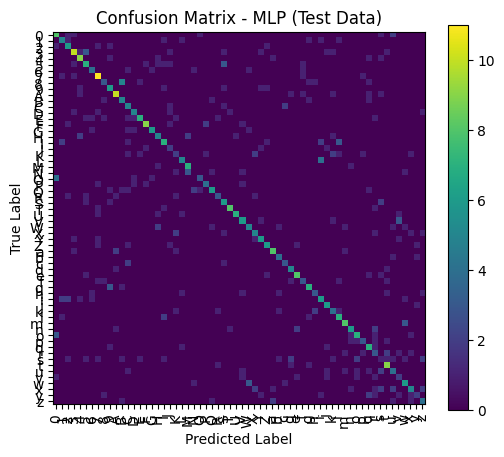

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_mlp)

print("Confusion Matrix Shape:", cm.shape)

labels = sorted(np.unique(y_test))

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix - MLP (Test Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)

plt.colorbar()
plt.show()
